# Test du raccord multi-segments / multi-détecteurs

Ce notebook teste le module `raccord_multisegment_sans_dq_reference_no_detector_underscore.py`.

Nouveautés prises en compte :

- les détecteurs sont nommés `detector0`, `detector1`, `detector2` ;
- on peut choisir une configuration ou un segment de référence pour l'échelle finale ;
- la sélection automatique peut rejeter les détecteurs redondants.


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Si le module SCARLET est installé :
import scarlet.reduction.stiching as st

# Si tu testes directement avec le fichier standalone fourni précédemment,
# tu peux remplacer la ligne ci-dessus par :
#
# sys.path.insert(0, "/chemin/vers/le/dossier_du_script")
# import raccord_multisegment_sans_dq as st

plt.rcParams["figure.figsize"] = (7.5, 5.0)


In [39]:
# Fichiers à raccorder.
# Adapte DATA_DIR si besoin.

DATA_DIR = Path("./data_SANS_LLB")

files = [
    DATA_DIR / "ludox_SM30_config_config_9_detector0.txt",
    DATA_DIR / "ludox_SM30_config_config_9_detector1.txt",
    DATA_DIR / "ludox_SM30_config_config_9_detector2.txt",
    DATA_DIR / "ludox_SM30_config_config_10_detector0.txt",
    DATA_DIR / "ludox_SM30_config_config_10_detector1.txt",
    DATA_DIR / "ludox_SM30_config_config_10_detector2.txt",
]

for path in files:
    print(path, "OK" if path.exists() else "MANQUANT")
config_ids = ['config_9', 'config_10']
nexus_files = ["/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/sans-llb2026n000988.nxs",
               "/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/sans-llb2026n001004.nxs"]

data_SANS_LLB/ludox_SM30_config_config_9_detector0.txt OK
data_SANS_LLB/ludox_SM30_config_config_9_detector1.txt OK
data_SANS_LLB/ludox_SM30_config_config_9_detector2.txt OK
data_SANS_LLB/ludox_SM30_config_config_10_detector0.txt OK
data_SANS_LLB/ludox_SM30_config_config_10_detector1.txt OK
data_SANS_LLB/ludox_SM30_config_config_10_detector2.txt OK


## Chargement des segments

Chaque fichier est converti en `CurveSegment`.

Les identifiants seront du type :

```text
segment    config_id    detector_id
c9d0       config_9     detector0
c10d0      config_10    detector0
```

Il n'y a donc plus d'underscore dans le nom du détecteur.


In [ ]:
segments = st.load_segments(files)

# load from nexus
segments = []
for file,conf_id  in zip(nexus_files, config_ids):
    segments += st.load_segment_from_nexus(file, config_id=conf_id)

summary = pd.DataFrame([
    seg.quality_summary(resolution_weight=0.50)
    for seg in segments
])

len(segments)

ValueError: --names doit contenir autant d'entrées que de détecteurs disponibles

## Visualisation des données brutes

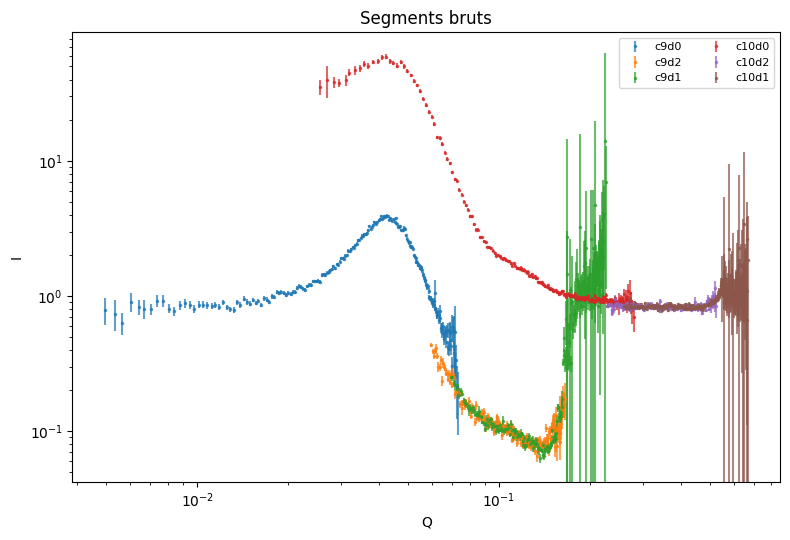

In [41]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for seg in segments:
    c = seg.curve
    ax.errorbar(c.q, c.i, yerr=c.di, fmt=".", markersize=3, alpha=0.7, label=seg.name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Q")
ax.set_ylabel("I")
ax.set_title("Segments bruts")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()


## Qualité des segments

On regarde d'abord :

\[
dI/I
\]

puis :

\[
dQ/Q
\]


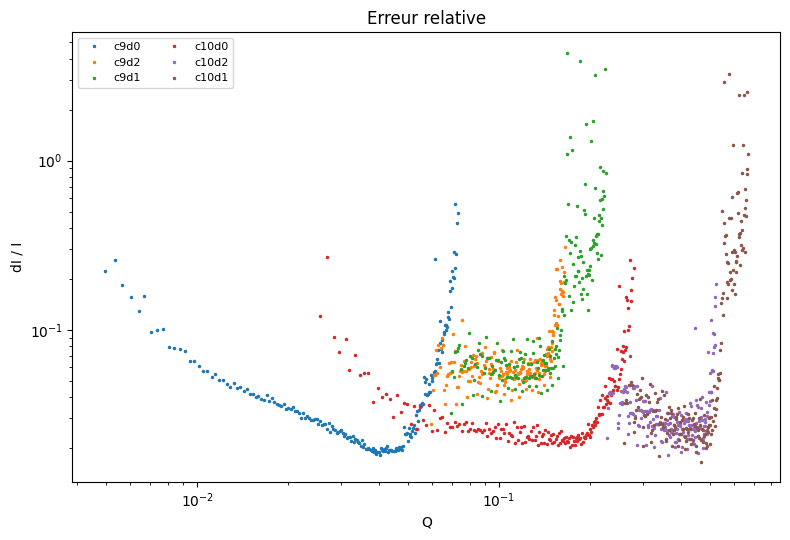

In [42]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for seg in segments:
    c = seg.curve
    ax.plot(c.q, c.di / c.i, ".", markersize=3, label=seg.name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Q")
ax.set_ylabel("dI / I")
ax.set_title("Erreur relative")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()


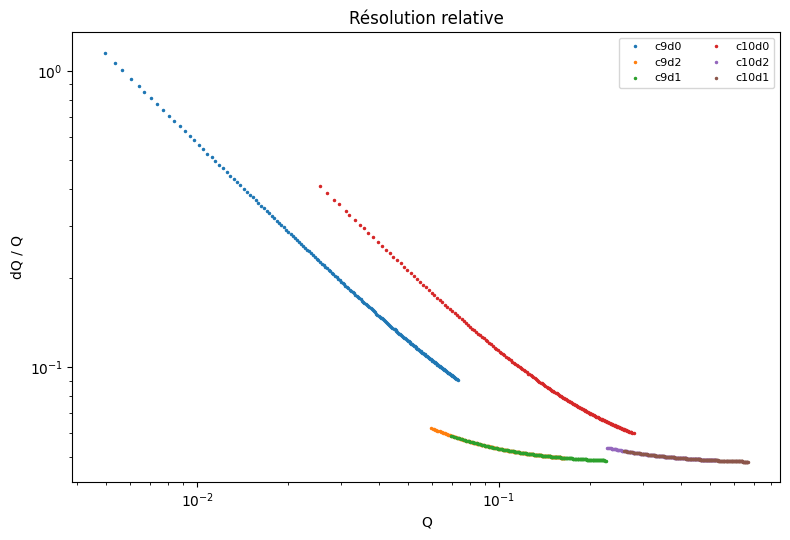

In [43]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for seg in segments:
    c = seg.curve
    ax.plot(c.q, c.dq / c.q, ".", markersize=3, label=seg.name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Q")
ax.set_ylabel("dQ / Q")
ax.set_title("Résolution relative")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()


## Sélection automatique des segments

La fonction `stitch_segments_greedy` sélectionne les segments utiles.

À ce stade, l'échelle interne est encore celle du premier segment retenu. On choisira la référence d'échelle dans la cellule suivante.


In [44]:
result = st.stitch_segments_greedy(
    segments,
    start_policy="lowest_q",
    grid="common",
    min_points=8,
    min_log_width=0.10,
    slope_weight=0.10,
    width_weight=0.05,
    resolution_weight=0.50,
    rho_ref=0.20,
    max_chi2_red=3.0,
    max_slope_z=2.5,
    min_new_log_coverage=0.05,
    segment_quality_weight=4.0,
    new_coverage_weight=1.5,
    keep_fraction=0.25,
)

st.selected_to_dataframe(result.selected)


,order,segment,config_id,detector_id,global_scale,q_min,q_max,median_dI_over_I,median_dQ_over_Q,quality_score,...,previous_segment,transition_scale_b_to_a,transition_scale_error,fit_q_min,fit_q_max,transition_chi2_red,transition_slope_z,transition_rho_resolution,transition_new_log_coverage,transition_score
0,0,c9d0,config_9,detector0,1.000000,0.004933,0.073314,0.034219,0.153280,0.029811,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,c10d0,config_10,detector0,0.046863,0.025514,0.279182,0.027079,0.083347,0.009337,...,c9d0,0.046863,0.001204,0.056713,0.073314,0.766496,0.537883,0.194746,1.337116,1.469506
2,2,c10d2,config_10,detector2,0.051083,0.228101,0.524046,0.029281,0.049804,0.003369,...,c10d0,1.090052,0.027357,0.250857,0.277528,0.259441,0.124519,0.080628,0.629715,0.442253
3,3,c10d1,config_10,detector1,0.050972,0.259885,0.667927,0.034504,0.048973,0.003696,...,c10d2,0.997838,0.007794,0.274522,0.334382,0.300660,0.183829,0.072203,0.242600,0.546982


## Choix de la référence d'échelle

On peut choisir la référence de trois façons.

### Par segment

```python
reference_segment="c10d0"
```

### Par configuration

```python
reference_config="config_10"
```

Si plusieurs détecteurs de la configuration sont retenus, le module choisit le segment de cette configuration qui couvre la plus grande largeur logarithmique en \(Q\).

### Par configuration + détecteur

```python
reference_config="config_10",
reference_detector="detector0"
```

Attention : le détecteur s'écrit maintenant `detector0`, sans underscore.


In [45]:
# Choix conseillé ici : exprimer la courbe finale dans l'échelle de config_10 detector0.
result = st.rebase_result_to_reference(
    result,
    reference_config="config_9",
    reference_detector="detector0",
)

selected_df = st.selected_to_dataframe(result.selected)
selected_df


,order,segment,config_id,detector_id,global_scale,q_min,q_max,median_dI_over_I,median_dQ_over_Q,quality_score,...,previous_segment,transition_scale_b_to_a,transition_scale_error,fit_q_min,fit_q_max,transition_chi2_red,transition_slope_z,transition_rho_resolution,transition_new_log_coverage,transition_score
0,0,c9d0,config_9,detector0,1.000000,0.004933,0.073314,0.034219,0.153280,0.029811,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,c10d0,config_10,detector0,0.046863,0.025514,0.279182,0.027079,0.083347,0.009337,...,c9d0,0.046863,0.001204,0.056713,0.073314,0.766496,0.537883,0.194746,1.337116,1.469506
2,2,c10d2,config_10,detector2,0.051083,0.228101,0.524046,0.029281,0.049804,0.003369,...,c10d0,1.090052,0.027357,0.250857,0.277528,0.259441,0.124519,0.080628,0.629715,0.442253
3,3,c10d1,config_10,detector1,0.050972,0.259885,0.667927,0.034504,0.048973,0.003696,...,c10d2,0.997838,0.007794,0.274522,0.334382,0.300660,0.183829,0.072203,0.242600,0.546982


## Segments rejetés

In [46]:
result.rejected

,segment,config_id,detector_id,q_min,q_max,quality_score,reason
0,c9d2,config_9,detector2,0.059695,0.166116,0.004974,rejected_redundant_or_no_new_q_coverage
1,c9d1,config_9,detector1,0.069127,0.226316,0.007228,rejected_redundant_or_no_new_q_coverage


## Raccords pair-à-pair testés

In [47]:
pair_fits = result.pair_fits.copy()

cols = [
    "segment_a",
    "segment_b",
    "scale_b_to_a",
    "fit_q_min",
    "fit_q_max",
    "chi2_red",
    "slope_z",
    "rho_resolution",
    "new_log_coverage",
    "accepted_transition",
    "score",
]

pair_fits[cols].sort_values("score").head(20)


,segment_a,segment_b,scale_b_to_a,fit_q_min,fit_q_max,chi2_red,slope_z,rho_resolution,new_log_coverage,accepted_transition,score
0,c10d0,c10d2,1.090052,0.250857,0.277528,0.259441,0.124519,0.080628,0.629715,True,0.442253
1,c10d2,c10d1,0.997838,0.274522,0.334382,0.300660,0.183829,0.072203,0.242600,True,0.546982
2,c9d0,c9d2,1.928067,0.064810,0.072118,0.532121,0.462995,0.112352,0.817936,True,0.807498
3,c9d2,c9d1,0.974891,0.101172,0.133900,0.669145,0.053887,0.073190,0.309248,True,0.892805
4,c9d1,c10d0,0.057964,0.104999,0.137848,0.525284,0.030478,0.110806,0.209933,True,0.896710
5,c9d2,c10d0,0.055687,0.100197,0.133051,0.756589,0.297547,0.113782,0.519180,True,1.107707
6,c9d0,c10d0,0.046863,0.056713,0.073314,0.766496,0.537883,0.194746,1.337116,True,1.469506


## Courbe finale

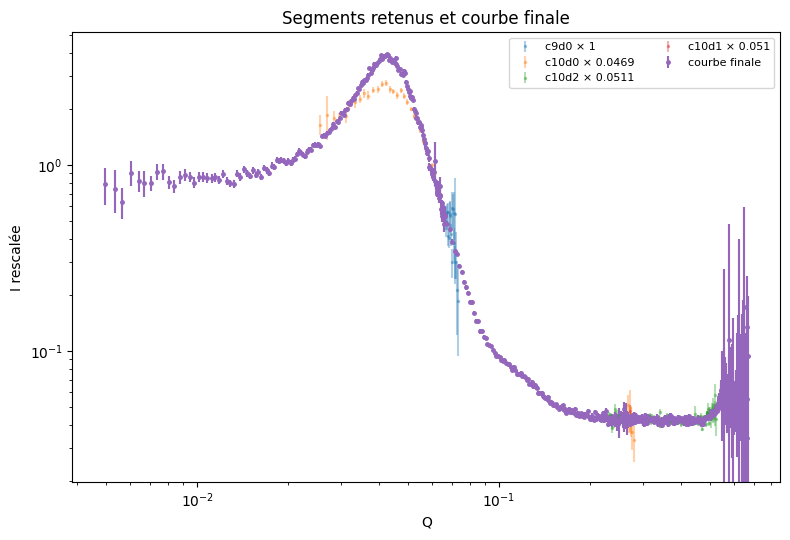

In [48]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for item in result.selected:
    seg = item.segment
    c = seg.curve.scaled(item.global_scale)
    ax.errorbar(
        c.q,
        c.i,
        yerr=c.di,
        fmt=".",
        markersize=3,
        alpha=0.35,
        label=f"{seg.name} × {item.global_scale:.3g}",
    )

c = result.final_curve
ax.errorbar(c.q, c.i, yerr=c.di, fmt="o", markersize=2.5, label="courbe finale")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Q")
ax.set_ylabel("I rescalée")
ax.set_title("Segments retenus et courbe finale")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()


## Sauvegarde des résultats

Cette cellule génère les mêmes diagnostics que le script en ligne de commande.


In [49]:
OUTDIR = DATA_DIR / "stitching_bis_multisegment_reference_no_detector_underscore_outputs"

st.save_outputs(
    segments,
    result,
    outdir=OUTDIR,
    resolution_weight=0.50,
)

print("Résultats écrits dans :", OUTDIR)
for path in sorted(OUTDIR.glob("*")):
    print(path.name)


Résultats écrits dans : data_SANS_LLB/stitching_bis_multisegment_reference_no_detector_underscore_outputs
01_raw_segments.png
02_relative_error.png
03_relative_resolution.png
04_selected_final_curve.png
05_retained_vs_rejected.png
06_transition_matrix.png
pairwise_overlap_fits.csv
rejected_segments.csv
result_summary.json
segments_quality_summary.csv
selected_segments.csv
selected_segments_stitched_curve.txt


## Exemple équivalent en ligne de commande

```bash
python raccord_multisegment_sans_dq_reference_no_detector_underscore.py \
  ludox_SM30_config_config_9_detector0.txt \
  ludox_SM30_config_config_9_detector1.txt \
  ludox_SM30_config_config_9_detector2.txt \
  ludox_SM30_config_config_10_detector0.txt \
  ludox_SM30_config_config_10_detector1.txt \
  ludox_SM30_config_config_10_detector2.txt \
  --outdir raccord_multi_ref_config10_d0 \
  --grid common \
  --reference-config config_10 \
  --reference-detector detector0
```


[CurveSegment(name='sans-llb2026n001005_detector0', curve=SASCurve(q=array([0.02551383, 0.02683451, 0.0283095 , 0.02942583, 0.03101728,
        0.03189265, 0.03326905, 0.03454047, 0.03560704, 0.03690803,
        0.03811983, 0.03961825, 0.04088705, 0.0421851 , 0.04350719,
        0.04465238, 0.04601004, 0.04718495, 0.04844205, 0.04965994,
        0.05091708, 0.05217204, 0.05359293, 0.05484875, 0.05618389,
        0.05745176, 0.05863996, 0.05996033, 0.0611313 , 0.06250657,
        0.0636125 , 0.0648578 , 0.06627498, 0.06746974, 0.06894368,
        0.0700685 , 0.07140918, 0.07261754, 0.07379326, 0.07529218,
        0.07632415, 0.07767541, 0.07885938, 0.08021698, 0.08161235,
        0.08269528, 0.08421587, 0.08530056, 0.08661101, 0.08791076,
        0.08906763, 0.09044622, 0.09152779, 0.09292719, 0.09419368,
        0.09549334, 0.09691538, 0.09801608, 0.09943506, 0.1005853 ,
        0.10192111, 0.10318118, 0.1043036 , 0.10557753, 0.10681456,
        0.1082034 , 0.10950636, 0.11077792, 0.11